In [1]:
import os

os.environ["HF_TOKEN"] = "your_actual_token_here"

from datasets import load_dataset
dataset= load_dataset("jason1966/adilshamim8_student-performance-and-learning-style")

In [2]:
import pandas as pd

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade'],
        num_rows: 14003
    })
})


In [3]:
from datasets import load_dataset

ds = load_dataset("jason1966/adilshamim8_student-performance-and-learning-style")

In [4]:
df = dataset["train"].to_pandas()

Checking Null value

In [5]:
import pandas as pd
from datasets import load_dataset

# Load your Hugging Face dataset
ds = load_dataset("jason1966/adilshamim8_student-performance-and-learning-style")

# Convert the train split to a Pandas DataFrame
df = pd.DataFrame(ds["train"])

In [6]:
df.isnull().sum()

,0
StudyHours,0
Attendance,0
Resources,0
Extracurricular,0
Motivation,0
Internet,0
Gender,0
Age,0
LearningStyle,0
OnlineCourses,0


In [7]:
df.isnull().sum().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [8]:
df.duplicated().sum()

np.int64(1534)

In [9]:
# Show all instances of duplicated rows
df[df.duplicated(keep=False)]
df.duplicated().sum()
#df.duplicated(subset=['Gender']).sum()

np.int64(1534)

In [10]:
df.duplicated().sum()


np.int64(1534)

In [11]:
# Remove duplicate rows directly in your DataFrame
df.drop_duplicates(inplace=True)

# Verify that duplicates are gone (should output 0)
df.duplicated().sum()

np.int64(0)

In [12]:
df.duplicated().sum()


np.int64(0)

In [13]:
print (df.describe())

         StudyHours    Attendance     Resources  Extracurricular  \
count  12469.000000  12469.000000  12469.000000     12469.000000   
mean      20.034405     80.239233      1.101371         0.583126   
std        6.049485     11.469028      0.711171         0.493061   
min        5.000000     60.000000      0.000000         0.000000   
25%       16.000000     70.000000      1.000000         0.000000   
50%       20.000000     80.000000      1.000000         1.000000   
75%       24.000000     90.000000      2.000000         1.000000   
max       44.000000    100.000000      2.000000         1.000000   

         Motivation      Internet        Gender           Age  LearningStyle  \
count  12469.000000  12469.000000  12469.000000  12469.000000   12469.000000   
mean       0.907370      0.917074      0.538616     23.529152       1.515358   
std        0.709599      0.275781      0.498527      3.510956       1.116071   
min        0.000000      0.000000      0.000000     18.000000      

In [14]:
# Display first few rows
print("--- First 5 Rows ---")
display(df.head())
# Count unique values per column
print("\n--- Unique Values Count ---")
print(df.nunique())

--- First 5 Rows ---


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2



--- Unique Values Count ---
StudyHours              37
Attendance              41
Resources                3
Extracurricular          2
Motivation               3
Internet                 2
Gender                   2
Age                     12
LearningStyle            4
OnlineCourses           21
Discussions              2
AssignmentCompletion    51
ExamScore               61
EduTech                  2
StressLevel              3
FinalGrade               4
dtype: int64


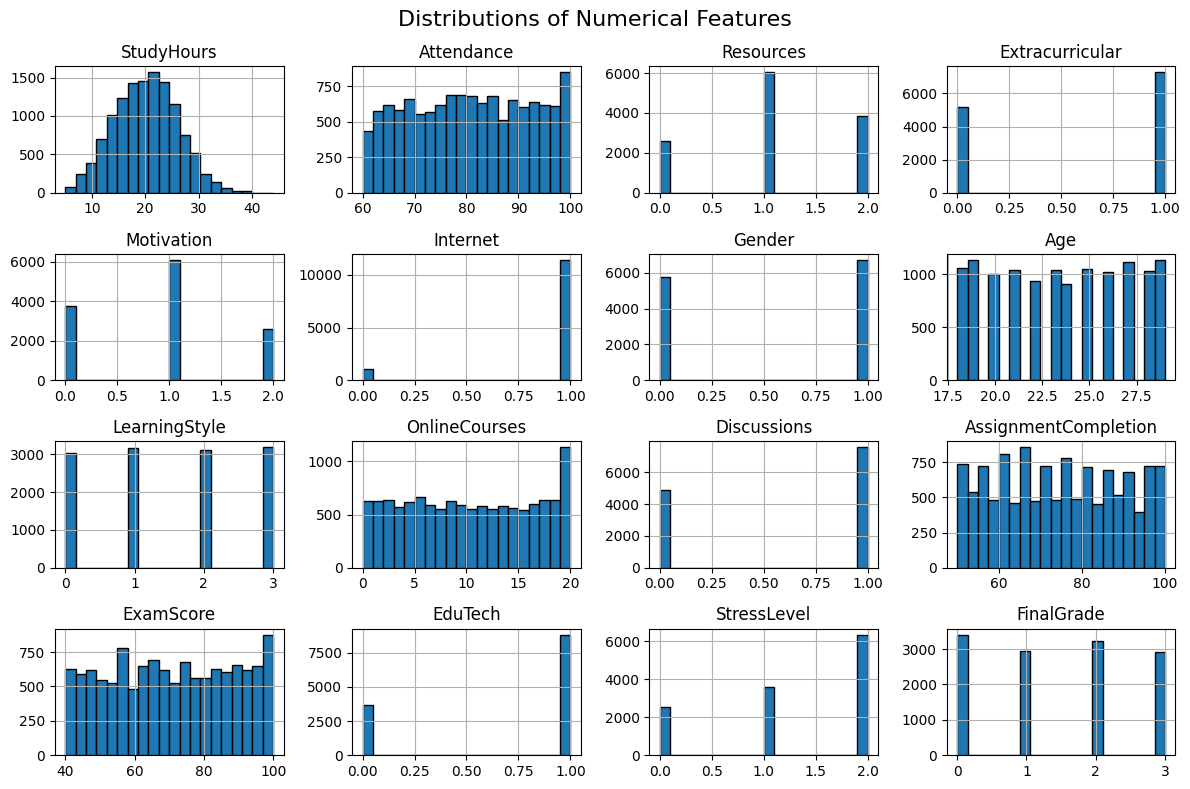

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot histograms for all numerical features
df.hist(figsize=(12, 8), bins=20, edgecolor='black')
plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:

# Identify non-numeric columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Value counts and bar plots for categorical variables
for col in cat_cols:
    print(f"\n--- Value Counts: {col} ---")
    print(df[col].value_counts(dropna=False))

    plt.figure(figsize=(6, 3))
    sns.countplot(data=df, x=col, palette="Set2")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

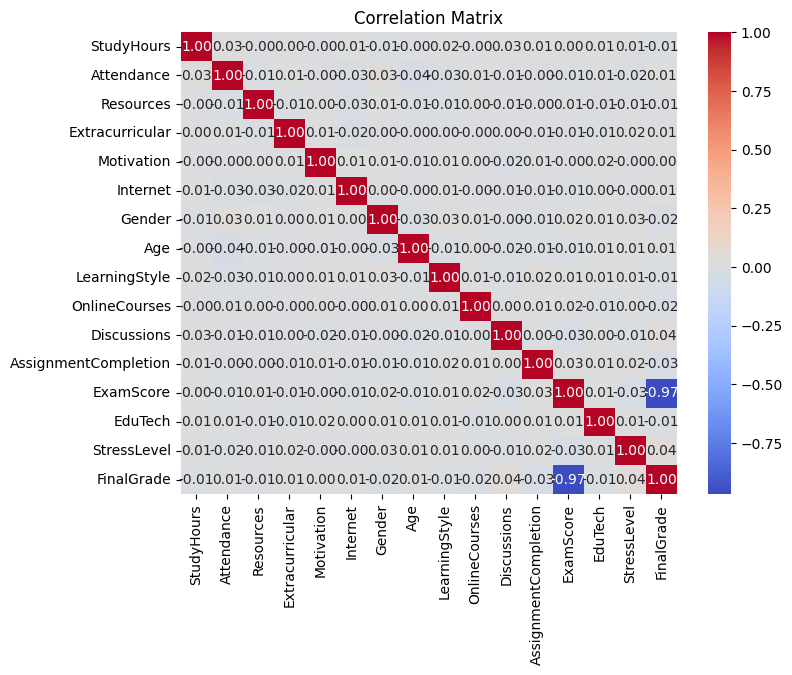

In [17]:
# Correlation Matrix (Numerical variables only)
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [21]:
# Calculate correlation matrix for numeric columns
correlation_matrix = df.select_dtypes(include=['number']).corr()

# 5. Key Statistical Insights
print("\n--- Key Correlations with Target Variable ---")
if target_col in correlation_matrix:
    target_corrs = correlation_matrix[target_col].sort_values(ascending=False)
    print(target_corrs)


--- Key Correlations with Target Variable ---
FinalGrade              1.000000
Discussions             0.039741
StressLevel             0.037786
Attendance              0.010870
Extracurricular         0.010560
Internet                0.006345
Age                     0.002903
Motivation              0.002726
Resources              -0.002907
StudyHours             -0.009623
EduTech                -0.017278
LearningStyle          -0.017735
OnlineCourses          -0.020984
Gender                 -0.022517
AssignmentCompletion   -0.030145
ExamScore              -0.968348
Name: FinalGrade, dtype: float64


Numerical Columns (16): ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']
Categorical Columns (1): ['Grade_Band']


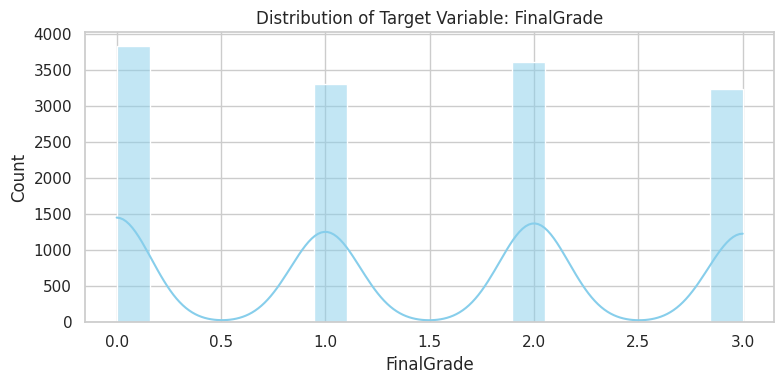

/tmp/ipykernel_1756/1720033834.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=first_cat, y=target_col, data=df, palette='Set2')


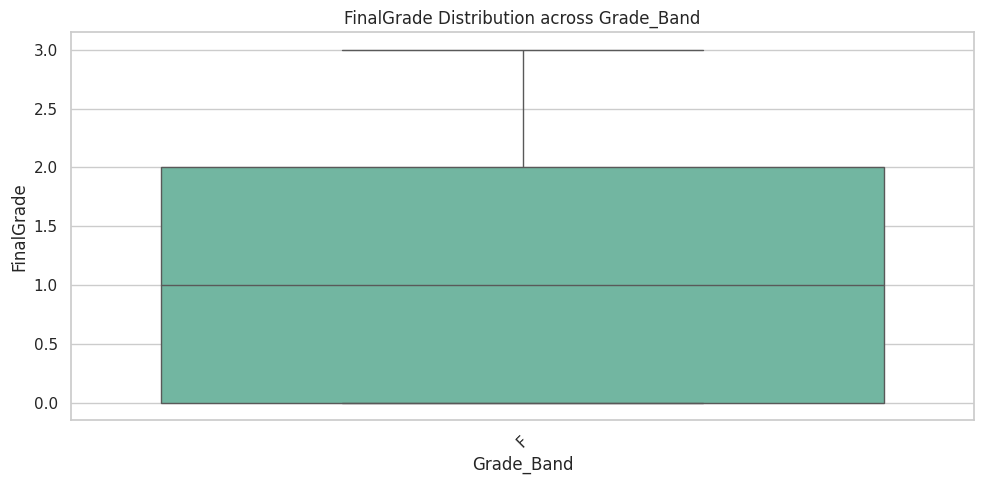


--- Key Correlations with Target Variable ---
FinalGrade              1.000000
Discussions             0.039741
StressLevel             0.037786
Attendance              0.010870
Extracurricular         0.010560
Internet                0.006345
Age                     0.002903
Motivation              0.002726
Resources              -0.002907
StudyHours             -0.009623
EduTech                -0.017278
LearningStyle          -0.017735
OnlineCourses          -0.020984
Gender                 -0.022517
AssignmentCompletion   -0.030145
ExamScore              -0.968348
Name: FinalGrade, dtype: float64


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# 1. Identify Target and Feature Types
# Automatically identify numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical Columns ({len(num_cols)}): {num_cols}")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")

# 2. Target Variable Distribution (Assuming 'FinalGrade' or similar column exists)
# Replace 'FinalGrade' if your target column name differs in the dataset
target_col = 'FinalGrade' if 'FinalGrade' in df.columns else num_cols[-1]

plt.figure(figsize=(8, 4))
sns.histplot(df[target_col], kde=True, color='skyblue')
plt.title(f'Distribution of Target Variable: {target_col}')
plt.xlabel(target_col)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3. Categorical Features vs Target
# Let's see how LearningStyle (or first categorical feature) impacts performance
if cat_cols:
    plt.figure(figsize=(10, 5))
    first_cat = cat_cols[0]  # e.g., 'LearningStyle'
    sns.boxplot(x=first_cat, y=target_col, data=df, palette='Set2')
    plt.title(f'{target_col} Distribution across {first_cat}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# 5. Key Statistical Insights
print("\n--- Key Correlations with Target Variable ---")
if target_col in correlation_matrix:
    target_corrs = correlation_matrix[target_col].sort_values(ascending=False)
    print(target_corrs)

**Preprocessing**

In [20]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# ==========================================================
# 1. Convert Hugging Face Dataset to Pandas DataFrame
# ==========================================================
df = dataset["train"].to_pandas()

# ==========================================================
# 2. Create Grade Bands (Target Variable)
# ==========================================================
def create_grade_bands(score):
    if score >= 85:
        return "A"
    elif score >= 70:
        return "B"
    elif score >= 55:
        return "C"
    elif score >= 40:
        return "D"
    else:
        return "F"

# Automatically identify the target column
target_col = "FinalGrade" if "FinalGrade" in df.columns else df.select_dtypes(include=["number"]).columns[-1]

# Create classification target
df["Grade_Band"] = df[target_col].apply(create_grade_bands)

print("Class Distribution")
print(df["Grade_Band"].value_counts())
print()

# ==========================================================
# 3. Separate Features and Target
# ==========================================================
X = df.drop(columns=[target_col, "Grade_Band"])
y = df["Grade_Band"]

# ==========================================================
# 4. Identify Numerical & Categorical Columns
# ==========================================================
X_num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
X_cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical Features:")
print(X_num_cols)

print("\nCategorical Features:")
print(X_cat_cols)

# ==========================================================
# 5. Build Preprocessor
# ==========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), X_num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), X_cat_cols)
    ]
)

# ==========================================================
# 6. Fit & Transform Features
# ==========================================================
X_processed = preprocessor.fit_transform(X)

# ==========================================================
# 7. Get Feature Names
# ==========================================================
feature_names = []

feature_names.extend(X_num_cols)

if len(X_cat_cols) > 0:
    cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(X_cat_cols)
    feature_names.extend(cat_names)

# ==========================================================
# 8. Convert Back to DataFrame
# ==========================================================
X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names,
    index=df.index
)

print("\nPreprocessing Completed Successfully!")
print(f"Original Shape : {X.shape}")
print(f"Processed Shape: {X_processed_df.shape}")

print("\nProcessed Data Preview")
print(X_processed_df.head())

Class Distribution
Grade_Band
F    14003
Name: count, dtype: int64

Numerical Features:
['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel']

Categorical Features:
[]

Preprocessing Completed Successfully!
Original Shape : (14003, 15)
Processed Shape: (14003, 15)

Processed Data Preview
   StudyHours  Attendance  Resources  Extracurricular  Motivation  Internet  \
0   -0.167633   -1.411667  -0.149721        -1.209965   -1.301687  0.283687   
1   -0.167633   -1.411667  -0.149721        -1.209965   -1.301687  0.283687   
2   -0.167633   -1.411667  -0.149721        -1.209965   -1.301687  0.283687   
3   -0.167633   -1.411667  -0.149721         0.826470   -1.301687  0.283687   
4   -0.167633   -1.411667  -0.149721         0.826470   -1.301687  0.283687   

     Gender       Age  LearningStyle  OnlineCourses  Discussions  \
0 -1.1

In [23]:
print(X_processed_df.shape)
print(y.head())

(14003, 15)
0    F
1    F
2    F
3    F
4    F
Name: Grade_Band, dtype: object


In [24]:
from sklearn.model_selection import train_test_split

# Total dataset size: ~14,003 rows
# Target ratio: 70% Train, 20% Test, 10% Validation
# Create 4 balanced grade bands (0, 1, 2, 3) using quartiles/percentiles
df['Grade_Band'] = pd.qcut(df['ExamScore'], q=4,labels=['F', 'C', 'B', 'A'])

# Re-assign target
y = df['Grade_Band']
# 1. First Split: Hold out 20% for Final Testing
# Remaining 80% will be temporary train/val data
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed_df,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. Second Split: Divide the 80% temp data into Train (70% total) and Validation (10% total)
# 0.125 of 80% = 10% of overall dataset
val_ratio_of_temp = 0.10 / 0.80  # 0.125

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_ratio_of_temp,
    random_state=42,
    stratify=y_temp
)


# Now re-run your Train-Val-Test split and model training!
# 3. Verify Set Shapes & Ratios
total_samples = len(X_processed_df)
print(f"Total Samples: {total_samples}")
print(f"--- Dataset Split Summary ---")
print(f"Training Set:   {X_train.shape[0]} samples ({X_train.shape[0] / total_samples * 100:.1f}%)")
print(f"Validation Set: {X_val.shape[0]} samples ({X_val.shape[0] / total_samples * 100:.1f}%)")
print(f"Test Set:       {X_test.shape[0]} samples ({X_test.shape[0] / total_samples * 100:.1f}%)")

# 4. Check Class Stratification Across Splits
print("\n--- Target Class Proportions (%) Across Splits ---")
split_df = pd.DataFrame({
    'Train (%)': y_train.value_counts(normalize=True) * 100,
    'Val (%)': y_val.value_counts(normalize=True) * 100,
    'Test (%)': y_test.value_counts(normalize=True) * 100
})
print(split_df.round(2))

Total Samples: 14003
--- Dataset Split Summary ---
Training Set:   9801 samples (70.0%)
Validation Set: 1401 samples (10.0%)
Test Set:       2801 samples (20.0%)

--- Target Class Proportions (%) Across Splits ---
            Train (%)  Val (%)  Test (%)
Grade_Band                              
B               25.42    25.41     25.42
F               25.34    25.34     25.35
C               25.12    25.12     25.10
A               24.12    24.13     24.13


In [25]:
print("X_processed_df" in globals())

True


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score

# 1. Encode Class Labels for XGBoost (requires integer labels: 0, 1, 2, 3, 4)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# 2. Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
}

# 3. Train and Evaluate Models on Validation Set
results = {}

print("--- Baseline Model Validation Results ---\n")

for name, model in models.items():
    # Fit model on Training Data
    model.fit(X_train, y_train_encoded)

    # Predict on Validation Data
    val_preds = model.predict(X_val)

    # Calculate Metrics
    acc = accuracy_score(y_val_encoded, val_preds)
    f1 = f1_score(y_val_encoded, val_preds, average='weighted')

    results[name] = {
        'model': model,
        'accuracy': acc,
        'f1_score': f1
    }

    print(f"=== {name} ===")
    print(f"Validation Accuracy: {acc * 100:.2f}%")
    print(f"Validation F1-Score: {f1 * 100:.2f}%")
    print("\nDetailed Classification Report:")
    print(classification_report(y_val_encoded, val_preds, target_names=label_encoder.classes_))
    print("-" * 50)

--- Baseline Model Validation Results ---

=== Logistic Regression ===
Validation Accuracy: 99.36%
Validation F1-Score: 99.36%

Detailed Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       338
           B       0.99      0.99      0.99       356
           C       0.98      0.99      0.99       352
           F       1.00      0.99      1.00       355

    accuracy                           0.99      1401
   macro avg       0.99      0.99      0.99      1401
weighted avg       0.99      0.99      0.99      1401

--------------------------------------------------
=== Random Forest ===
Validation Accuracy: 100.00%
Validation F1-Score: 100.00%

Detailed Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       338
           B       1.00      1.00      1.00       356
           C       1.00      1.00      1.00       352
           F       1.00 

MODEL VALIDATION RESULTS

Logistic Regression
Accuracy : 93.07%
Precision: 93.43%
Recall   : 93.07%
F1 Score : 93.06%

Classification Report

              precision    recall  f1-score   support

           A       0.87      1.00      0.93       675
           B       0.94      0.86      0.90       712
           C       0.92      0.94      0.93       703
           F       1.00      0.92      0.96       710

    accuracy                           0.93      2800
   macro avg       0.93      0.93      0.93      2800
weighted avg       0.93      0.93      0.93      2800



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


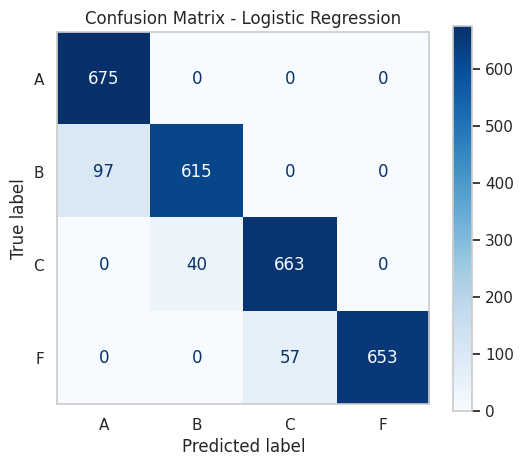


Random Forest
Accuracy : 93.07%
Precision: 93.43%
Recall   : 93.07%
F1 Score : 93.06%

Classification Report

              precision    recall  f1-score   support

           A       0.87      1.00      0.93       675
           B       0.94      0.86      0.90       712
           C       0.92      0.94      0.93       703
           F       1.00      0.92      0.96       710

    accuracy                           0.93      2800
   macro avg       0.93      0.93      0.93      2800
weighted avg       0.93      0.93      0.93      2800



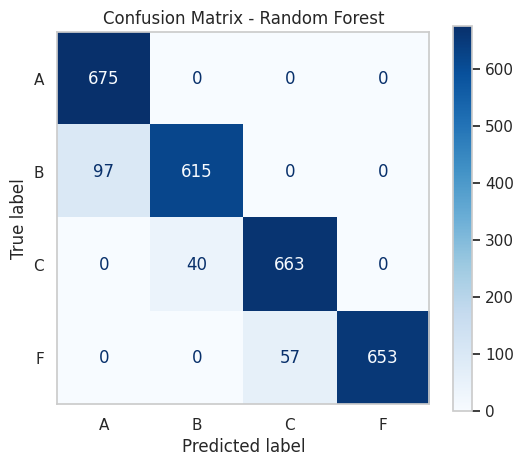


XGBoost
Accuracy : 93.11%
Precision: 93.46%
Recall   : 93.11%
F1 Score : 93.10%

Classification Report

              precision    recall  f1-score   support

           A       0.88      1.00      0.93       675
           B       0.94      0.87      0.90       712
           C       0.92      0.94      0.93       703
           F       1.00      0.92      0.96       710

    accuracy                           0.93      2800
   macro avg       0.93      0.93      0.93      2800
weighted avg       0.93      0.93      0.93      2800



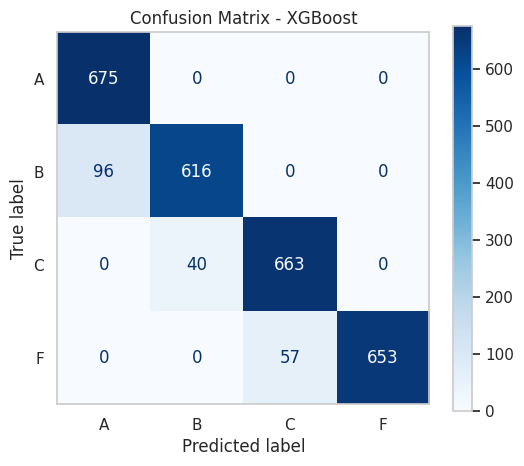


Support Vector Machine
Accuracy : 50.04%
Precision: 52.00%
Recall   : 50.04%
F1 Score : 45.61%

Classification Report

              precision    recall  f1-score   support

           A       0.53      0.06      0.11       675
           B       0.41      0.65      0.50       712
           C       0.49      0.59      0.53       703
           F       0.65      0.68      0.67       710

    accuracy                           0.50      2800
   macro avg       0.52      0.50      0.45      2800
weighted avg       0.52      0.50      0.46      2800



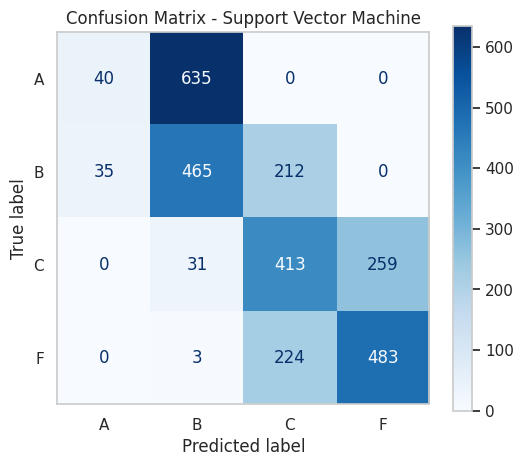


Gradient Boosting
Accuracy : 93.54%
Precision: 93.84%
Recall   : 93.54%
F1 Score : 93.53%

Classification Report

              precision    recall  f1-score   support

           A       0.88      1.00      0.94       675
           B       0.94      0.87      0.91       712
           C       0.93      0.94      0.94       703
           F       1.00      0.93      0.96       710

    accuracy                           0.94      2800
   macro avg       0.94      0.94      0.94      2800
weighted avg       0.94      0.94      0.94      2800



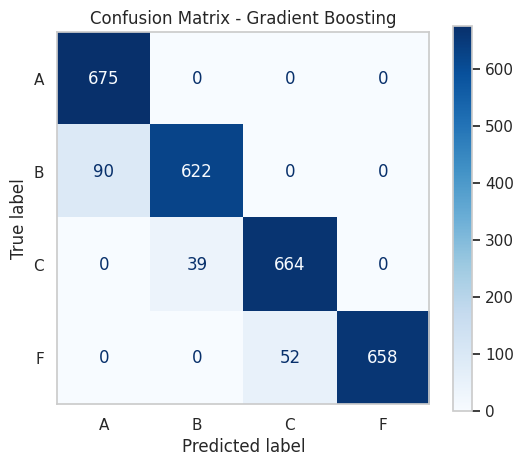



FINAL MODEL COMPARISON
                 Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
     Gradient Boosting         93.54          93.84       93.54         93.53
               XGBoost         93.11          93.46       93.11         93.10
   Logistic Regression         93.07          93.43       93.07         93.06
         Random Forest         93.07          93.43       93.07         93.06
Support Vector Machine         50.04          52.00       50.04         45.61


In [28]:
# ==========================================================
# Import Libraries
# ==========================================================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================================
# Prepare Features and Target
# ==========================================================

# Features
X = df.drop(columns=["Grade_Band", "ExamScore"])

# Target
y = df["Grade_Band"]

# ==========================================================
# Train / Validation / Test Split
# 70% Train | 20% Validation | 10% Test
# ==========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=1/3,
    random_state=42,
    stratify=y_temp
)

# ==========================================================
# Encode Target Labels
# ==========================================================

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# ==========================================================
# Define Models
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        objective="multi:softmax",
        num_class=len(label_encoder.classes_),
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="mlogloss"
    ),

    "Support Vector Machine": SVC(
        kernel="rbf",
        C=1.0,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}

# ==========================================================
# Train Models & Evaluate
# ==========================================================

results = []

print("=" * 70)
print("MODEL VALIDATION RESULTS")
print("=" * 70)

for name, model in models.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    # Train
    model.fit(X_train, y_train_encoded)

    # Predict
    val_preds = model.predict(X_val)

    # Metrics
    accuracy = accuracy_score(y_val_encoded, val_preds)

    precision = precision_score(
        y_val_encoded,
        val_preds,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_val_encoded,
        val_preds,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_val_encoded,
        val_preds,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 Score (%)": f1 * 100
    })

    print(f"Accuracy : {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall   : {recall*100:.2f}%")
    print(f"F1 Score : {f1*100:.2f}%")

    print("\nClassification Report\n")

    print(
        classification_report(
            y_val_encoded,
            val_preds,
            target_names=label_encoder.classes_
        )
    )

    # ======================================================
    # Confusion Matrix
    # ======================================================

    cm = confusion_matrix(y_val_encoded, val_preds)

    fig, ax = plt.subplots(figsize=(6,5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    disp.plot(
        cmap="Blues",
        ax=ax,
        values_format="d"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()

# ==========================================================
# Final Comparison Table
# ==========================================================

comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="F1 Score (%)",
    ascending=False
)

comparison = comparison.round(2)

print("\n")
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(comparison.to_string(index=False))

In [29]:
results = []
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train_encoded)

    trained_models[name] = model

    val_preds = model.predict(X_val)

    ...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SHAP

PermutationExplainer explainer: 1402it [05:32,  4.17it/s]
/tmp/ipykernel_1756/2763340430.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


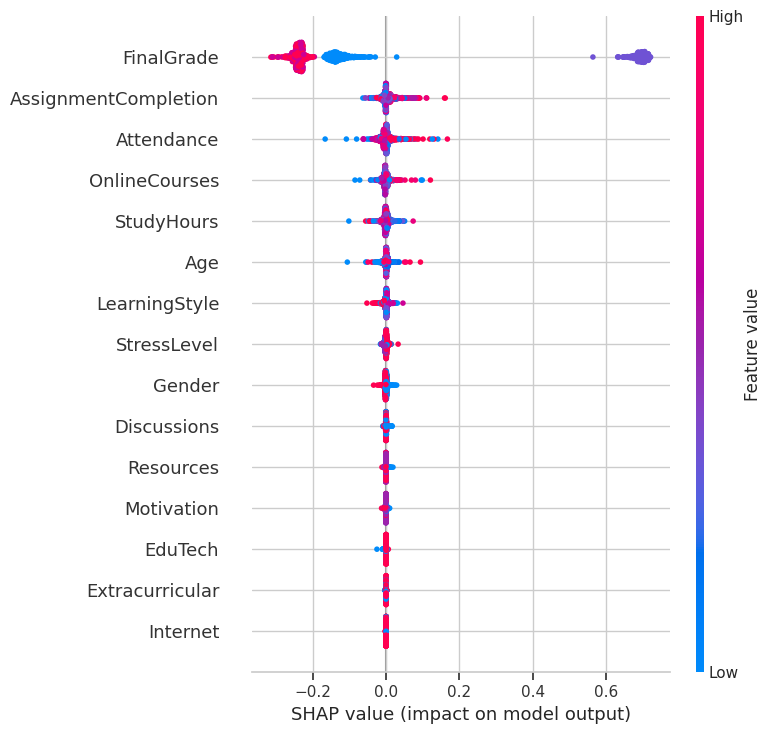

In [35]:
import shap

# Pass final_model.predict_proba (or final_model.predict) as the model argument
explainer = shap.Explainer(final_model.predict_proba, X_train)

# Compute SHAP values
shap_values = explainer(X_test)

# For multi-class or binary classification, pick the relevant target class slice (e.g., positive class)
shap.summary_plot(shap_values[:, :, 1], X_test)

In [36]:
import matplotlib.pyplot as plt
from google.colab import files  # For Google Colab users

# 1. Clear any previous plots
plt.figure(figsize=(10, 6))

# 2. Run your SHAP plot (ensure show=False so Matplotlib can capture it)
shap.summary_plot(shap_values, X_test, show=False)

# 3. Save as a PNG file
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches='tight')
plt.close()

# 4. Trigger direct download in Colab
files.download("shap_summary_plot.png")

/tmp/ipykernel_1756/3415893885.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
from google.colab import files  # Omit this import if running standard Jupyter locally

# 1. Store your trained models in a dictionary
models = {
    "Gradient Boosting": final_model,
    # "Random Forest": rf_model,      # Add other trained model variables here
    # "Logistic Regression": lr_model
}

# 2. Set up the figure layout (adjust grid columns based on number of models)
num_models = len(models)
fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5))

# Handle single model case so axes is always iterable
if num_models == 1:
    axes = [axes]
# Convert probabilities/continuous predictions to 0 or 1 labels
y_pred = (model.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
# OR simply:
y_pred = model.predict(X_test)
# 3. Plot confusion matrix for each model side-by-side
for ax, (model_name, model) in zip(axes, models.items()):

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])

    ax.set_title(f'Confusion Matrix: {model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()

# 4. Save the combined plot to a single PNG file
file_name = "all_models_confusion_matrices.png"
plt.savefig(file_name, dpi=300, bbox_inches='tight')
plt.close()

# 5. Download the single image file (Google Colab)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>